# Baseline Model

## 1. Import data + Set up

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from functions import load_splits, evaluate, LABELS, RANDOM_STATE

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = load_splits()
scores = []

## 2. Train / validation / test split

The split (70/15/15, stratified, `random_state=42`) is defined once in `functions.py`,
so every model — baseline and transfer learning — uses exactly the same data.

In [3]:
from functions import load_splits, evaluate, LABELS, RANDOM_STATE
X_train, X_val, X_test, y_train, y_val, y_test = load_splits()

## 3. Baseline 

### 3.1 Dummy Classifier

=== Dummy (most frequent) ===
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       121
     Neutral       0.00      0.00      0.00       225
    Positive       0.93      1.00      0.97      4848

    accuracy                           0.93      5194
   macro avg       0.31      0.33      0.32      5194
weighted avg       0.87      0.93      0.90      5194



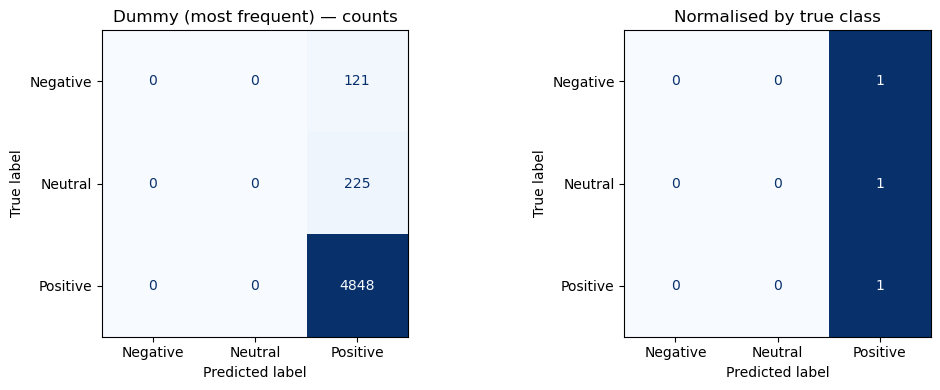

In [4]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
scores.append(evaluate(y_val, dummy.predict(X_val), "Dummy (most frequent)"))

## 3.2 Baseline
    - TF-IDF
    - Logistical Regression (balanced weights)

=== TF-IDF + LogReg (balanced) ===
              precision    recall  f1-score   support

    Negative       0.37      0.54      0.44       121
     Neutral       0.23      0.44      0.30       225
    Positive       0.97      0.92      0.95      4848

    accuracy                           0.89      5194
   macro avg       0.53      0.63      0.56      5194
weighted avg       0.93      0.89      0.91      5194



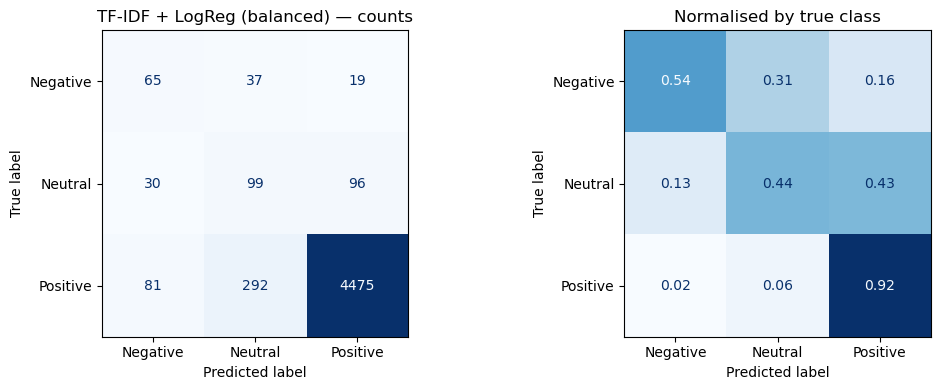

In [5]:
logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
        strip_accents="unicode",
        stop_words="english")),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE)),
])

logreg.fit(X_train, y_train)
scores.append(evaluate(y_val, logreg.predict(X_val), "TF-IDF + LogReg (balanced)"))

## 4. Comparing models

Comparing Dummy with TF-IDF + Log Reg table:

    - Dummy high accuracy bc not taking into consideration negative or neutral, so it fails on the F1 macro
    
    - TF-IDF + logReg: the model to beat! F1 macro **0.56**

,accuracy,f1_macro,f1_negative,f1_neutral,f1_positive
model,,,,,
TF-IDF + LogReg (balanced),0.8931,0.5631,0.4377,0.3032,0.9483
Dummy (most frequent),0.9334,0.3218,0.0000,0.0000,0.9655


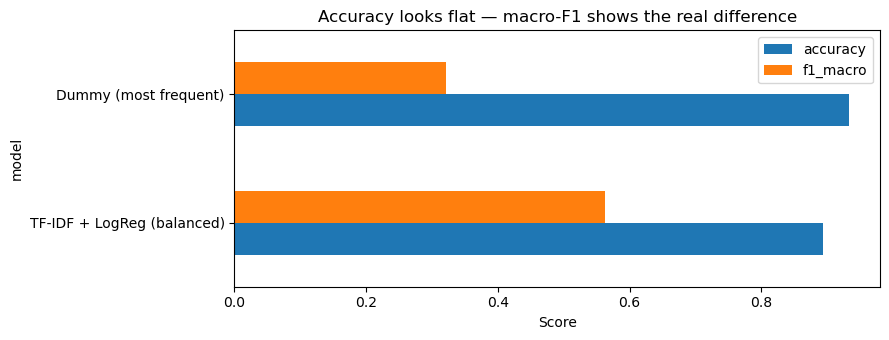

In [6]:
cmp = (pd.DataFrame(scores)
         .set_index("model")
         .sort_values("f1_macro", ascending=False)
         .round(4))

display(cmp[["accuracy", "f1_macro", "f1_negative", "f1_neutral", "f1_positive"]])

ax = cmp[["accuracy", "f1_macro"]].plot(kind="barh", figsize=(9, 3.5))
ax.set_xlabel("Score")
ax.set_title("Accuracy looks flat — macro-F1 shows the real difference")
plt.tight_layout(); plt.show()

## 5. Final Evaluation on Test Set

=== FINAL BASELINE — test set ===
              precision    recall  f1-score   support

    Negative       0.37      0.57      0.44       122
     Neutral       0.22      0.44      0.30       225
    Positive       0.98      0.92      0.95      4847

    accuracy                           0.89      5194
   macro avg       0.52      0.64      0.56      5194
weighted avg       0.93      0.89      0.91      5194



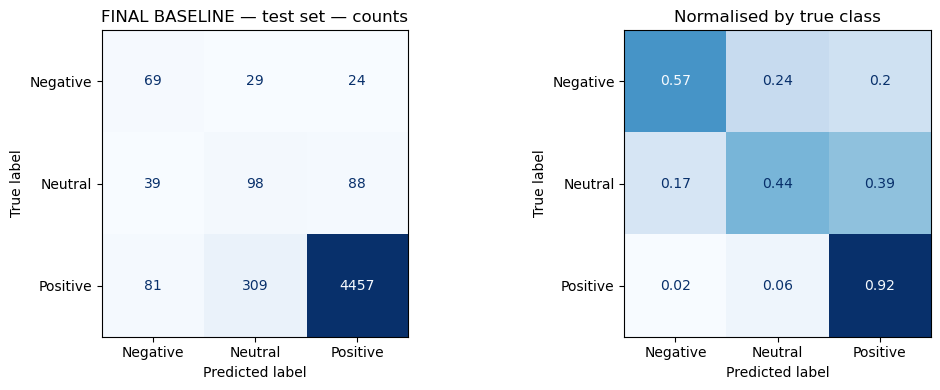

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,FINAL BASELINE — test set,0.8903,0.6402,0.5623,0.9067,0.4437,0.2965,0.9467


In [7]:
test_results = evaluate(y_test, logreg.predict(X_test),
                        "FINAL BASELINE — test set")

pd.DataFrame([test_results]).round(4)